In [2]:
import ujson
import numpy as np
import matplotlib.pyplot as plt
import collections
import seaborn as sns

In [3]:
DATA_FILE = '/cmlscratch/snawathe/cmsc828g-proj/results/baseline.jsonl'

,epoch,gpu_id,throughput
0,0,0,49.214117
1,0,1,67.616047
2,0,2,79.656024
3,0,3,70.750907
4,1,0,65.553519
5,1,1,76.742885
6,1,2,50.527932
7,1,3,55.230497
8,2,0,73.422536
9,2,1,74.966895


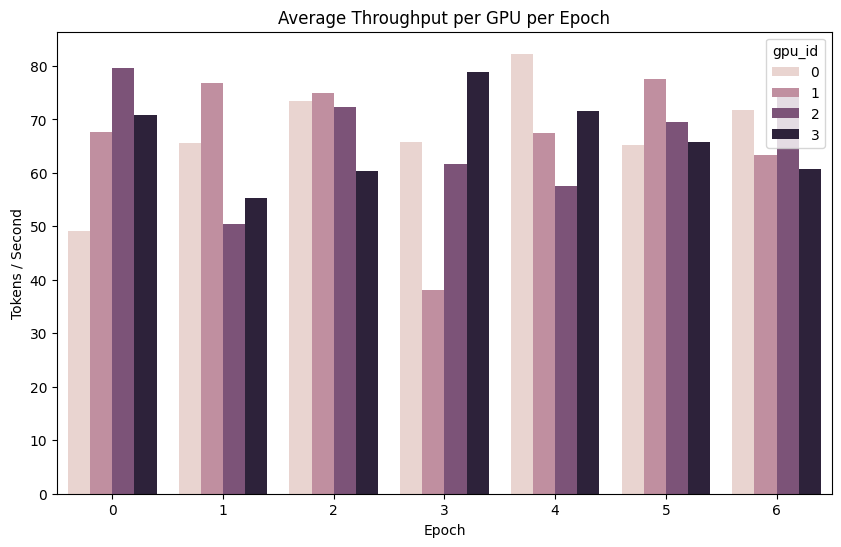

In [4]:
import pandas as pd

records = []
with open(DATA_FILE, 'r') as f:
    for line in f:
        records.append(ujson.loads(line))

batch_records = [r for r in records if r.get('type') == 'batch']

data = []
for r in batch_records:
    epoch = r['epoch']
    gpu_id = r['gpu_id']
    gen_time = r['generation_time']
    # output_token_lengths is a list of lists of ints
    total_tokens = sum(sum(lengths) for lengths in r['output_token_lengths'])
    
    if r.get('oom_occurred'):
        total_tokens += 240_000
        
    throughput = total_tokens / gen_time if gen_time > 0 else 0
    data.append({
        'epoch': epoch,
        'gpu_id': gpu_id,
        'throughput': throughput
    })

df = pd.DataFrame(data)
throughput_summary = df.groupby(['epoch', 'gpu_id'])['throughput'].mean().reset_index()
display(throughput_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=throughput_summary, x='epoch', y='throughput', hue='gpu_id')
plt.title('Average Throughput per GPU per Epoch')
plt.ylabel('Tokens / Second')
plt.xlabel('Epoch')
plt.show()

In [5]:
BASELINE = '/cmlscratch/snawathe/cmsc828g-proj/results/baseline.jsonl'
MAXT = '/cmlscratch/snawathe/cmsc828g-proj/results/maxt.jsonl'
SUMT = '/cmlscratch/snawathe/cmsc828g-proj/results/sumt.jsonl'

Processing Baseline data from /cmlscratch/snawathe/cmsc828g-proj/results/baseline.jsonl...
Processing MaxT data from /cmlscratch/snawathe/cmsc828g-proj/results/maxt.jsonl...
Processing SumT data from /cmlscratch/snawathe/cmsc828g-proj/results/sumt.jsonl...


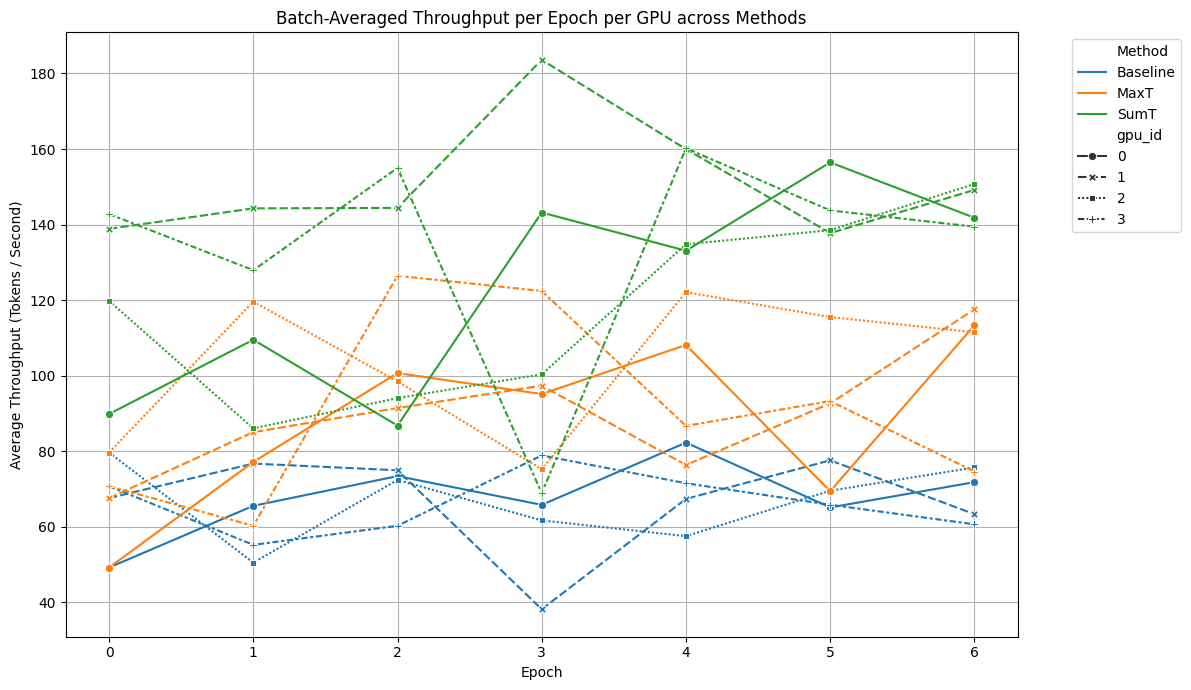

In [25]:
import os

all_data = []
methods = {'Baseline': BASELINE, 'MaxT': MAXT, 'SumT': SUMT}

for method, path in methods.items():
    if not os.path.exists(path):
        print(f"Warning: {path} does not exist.")
        continue
    else:
        print(f"Processing {method} data from {path}...")
    
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            try:
                r = ujson.loads(line)
            except ValueError:
                continue
            if r.get('type') == 'batch':
                epoch = r['epoch']
                gpu_id = r['gpu_id']
                gen_time = r['generation_time']
                total_tokens = sum(sum(lengths) for lengths in r['output_token_lengths'])
                
                if r.get('oom_occurred'):
                    total_tokens += 240_000
                    
                throughput = total_tokens / gen_time if gen_time > 0 else 0
                
                all_data.append({
                    'Method': method,
                    'epoch': epoch,
                    'gpu_id': gpu_id,
                    'throughput': throughput
                })

df_all = pd.DataFrame(all_data)

if not df_all.empty:
    # Group by Method, epoch, and gpu_id to average across batches for that specific GPU/Epoch pair
    throughput_summary = df_all.groupby(['Method', 'epoch', 'gpu_id'])['throughput'].mean().reset_index()

    plt.figure(figsize=(12, 7))
    sns.lineplot(
        data=throughput_summary, 
        x='epoch', 
        y='throughput', 
        hue='Method', 
        style='gpu_id', 
        markers=True,
        dashes=True
    )
    plt.title('Batch-Averaged Throughput per Epoch per GPU across Methods')
    plt.ylabel('Average Throughput (Tokens / Second)')
    plt.xlabel('Epoch')
    # Move the legend outside to avoid obscuring the graph
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No data found.")

Processing Baseline data from /cmlscratch/snawathe/cmsc828g-proj/results/baseline.jsonl...
Processing MaxT data from /cmlscratch/snawathe/cmsc828g-proj/results/maxt.jsonl...
Processing SumT data from /cmlscratch/snawathe/cmsc828g-proj/results/sumt.jsonl...


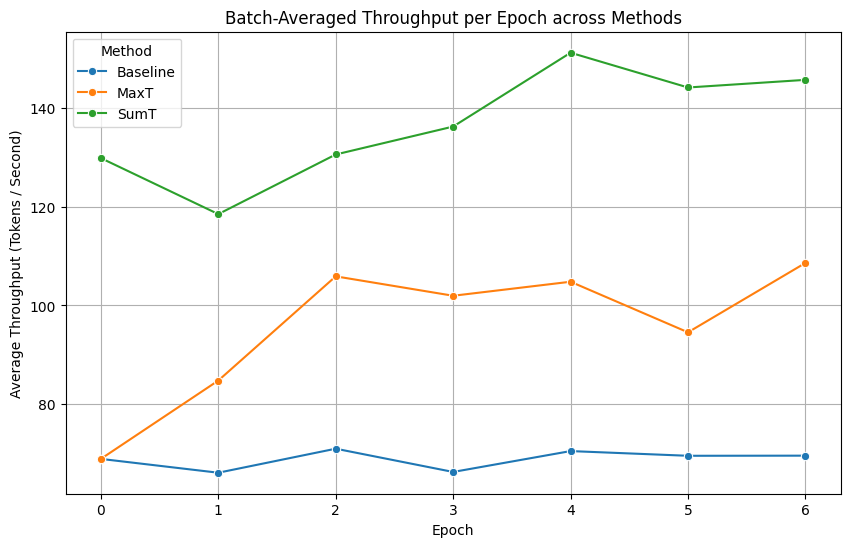

In [28]:
import os

all_data = []
methods = {'Baseline': BASELINE, 'MaxT': MAXT, 'SumT': SUMT}

for method, path in methods.items():
    if not os.path.exists(path):
        print(f"Warning: {path} does not exist.")
        continue
    else:
        print(f"Processing {method} data from {path}...")
    
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            try:
                r = ujson.loads(line)
            except ValueError:
                continue
            if r.get('type') == 'batch':
                epoch = r['epoch']
                gen_time = r['generation_time']
                total_tokens = sum(sum(lengths) for lengths in r['output_token_lengths'])
                
                if r.get('oom_occurred'):
                    total_tokens += 240_000
                    
                throughput = total_tokens / gen_time if gen_time > 0 else 0
                
                all_data.append({
                    'Method': method,
                    'epoch': epoch,
                    'throughput': throughput
                })

df_all = pd.DataFrame(all_data)

if not df_all.empty:
    # Group by Method and epoch to average across all batches/GPUs
    throughput_summary = df_all.groupby(['Method', 'epoch'])['throughput'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=throughput_summary, x='epoch', y='throughput', hue='Method', marker='o')
    plt.title('Batch-Averaged Throughput per Epoch across Methods')
    plt.ylabel('Average Throughput (Tokens / Second)')
    plt.xlabel('Epoch')
    plt.grid(True)
    plt.show()
else:
    print("No data found.")

In [27]:
import os
import pandas as pd
from IPython.display import display, HTML

counts_data = []
methods = {'Baseline': BASELINE, 'MaxT': MAXT, 'SumT': SUMT}

for method, path in methods.items():
    if not os.path.exists(path):
        print(f"Warning: {path} does not exist.")
        continue
    
    with open(path, 'r') as f:
        for line in f:
            try:
                r = ujson.loads(line)
            except ValueError:
                continue
            if r.get('type') == 'batch':
                counts_data.append({
                    'Method': method,
                    'gpu_id': r['gpu_id'],
                    'epoch': r['epoch']
                })

df_counts = pd.DataFrame(counts_data)

if not df_counts.empty:
    for method in methods.keys():
        df_m = df_counts[df_counts['Method'] == method]
        if not df_m.empty:
            print(f"=== {method} ===")
            # Use pivot_table with aggfunc='size' to count rows (batches) for each gpu/epoch pair
            pivot_table = df_m.pivot_table(index='gpu_id', columns='epoch', aggfunc='size', fill_value=0)
            display(pivot_table)
            print("\n")
else:
    print("No data found.")

=== Baseline ===


epoch,0,1,2,3,4,5,6
gpu_id,,,,,,,
0,8,12,15,18,14,13,13
1,16,21,10,5,11,13,12
2,15,6,16,11,11,12,18
3,11,11,9,16,14,12,7




=== MaxT ===


epoch,0,1,2,3,4,5,6
gpu_id,,,,,,,
0,8,5,10,11,8,7,11
1,16,6,6,8,5,10,15
2,15,6,9,5,14,10,6
3,11,7,10,12,7,11,6




=== SumT ===


epoch,0,1,2,3,4,5,6
gpu_id,,,,,,,
0,5,2,3,7,3,6,8
1,16,3,5,7,10,7,3
2,14,3,3,5,6,5,10
3,15,4,7,3,7,6,5


Processing Baseline data from /cmlscratch/snawathe/cmsc828g-proj/results/baseline.jsonl...
Processing MaxT data from /cmlscratch/snawathe/cmsc828g-proj/results/maxt.jsonl...
Processing SumT data from /cmlscratch/snawathe/cmsc828g-proj/results/sumt.jsonl...


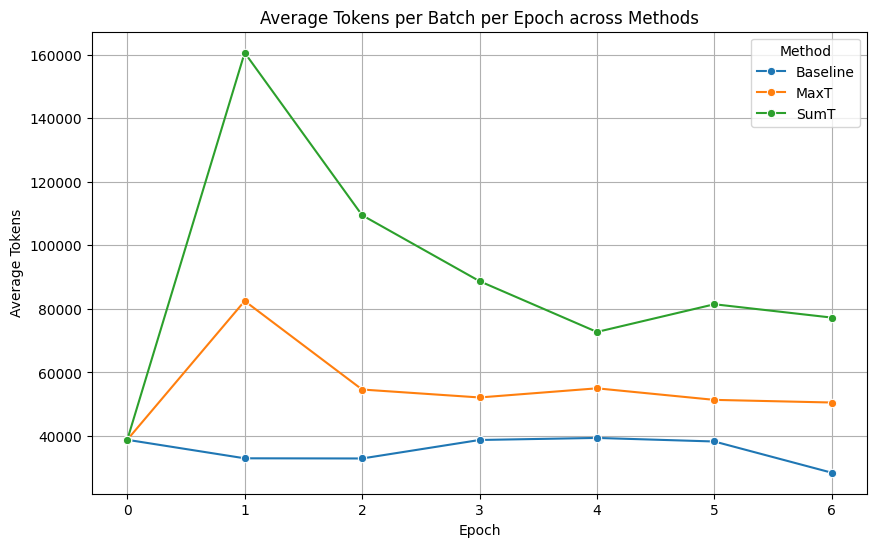

In [31]:
import os

all_data = []
methods = {'Baseline': BASELINE, 'MaxT': MAXT, 'SumT': SUMT}

for method, path in methods.items():
    if not os.path.exists(path):
        print(f"Warning: {path} does not exist.")
        continue
    else:
        print(f"Processing {method} data from {path}...")
    
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            try:
                r = ujson.loads(line)
            except ValueError:
                continue
            if r.get('type') == 'batch':
                epoch = r['epoch']
                gen_time = r['generation_time']
                total_tokens = sum(sum(lengths) for lengths in r['output_token_lengths'])
                
                # if r.get('oom_occurred'):
                #     total_tokens += 240_000
                
                all_data.append({
                    'Method': method,
                    'epoch': epoch,
                    'total_tokens': total_tokens
                })

df_all = pd.DataFrame(all_data)

if not df_all.empty:
    # Group by Method and epoch to average across all batches/GPUs
    throughput_summary = df_all.groupby(['Method', 'epoch'])['total_tokens'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=throughput_summary, x='epoch', y='total_tokens', hue='Method', marker='o')
    plt.title('Average Tokens per Batch per Epoch across Methods')
    plt.ylabel('Average Tokens')
    plt.xlabel('Epoch')
    plt.grid(True)
    plt.show()
else:
    print("No data found.")

Processing Baseline data from /cmlscratch/snawathe/cmsc828g-proj/results/baseline.jsonl...
Processing MaxT data from /cmlscratch/snawathe/cmsc828g-proj/results/maxt.jsonl...
Processing SumT data from /cmlscratch/snawathe/cmsc828g-proj/results/sumt.jsonl...


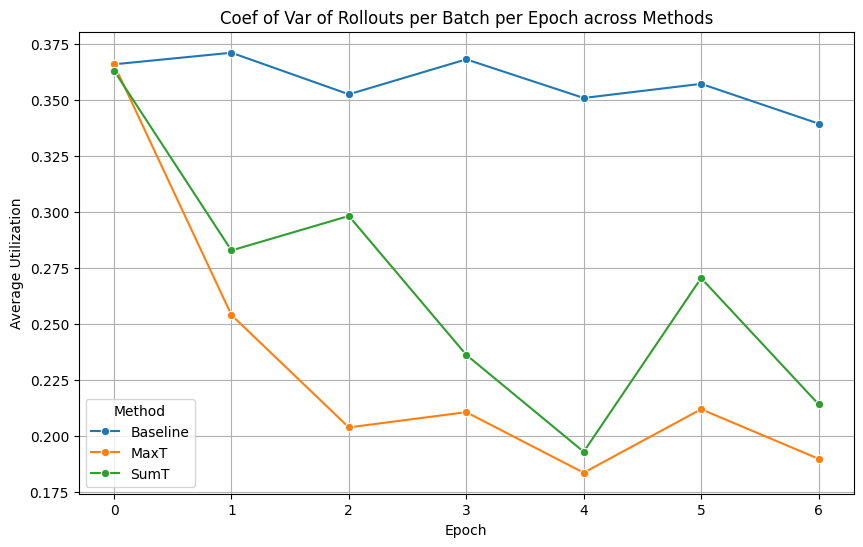

In [7]:
import os

all_data = []
methods = {'Baseline': BASELINE, 'MaxT': MAXT, 'SumT': SUMT}

for method, path in methods.items():
    if not os.path.exists(path):
        print(f"Warning: {path} does not exist.")
        continue
    else:
        print(f"Processing {method} data from {path}...")
    
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            try:
                r = ujson.loads(line)
            except ValueError:
                continue
            if r.get('type') == 'batch':
                epoch = r['epoch']
                gen_time = r['generation_time']
                lst = []
                for lengths in r['output_token_lengths']:
                    lst.extend(lengths)
                if len(lst) == 0:
                    continue
                # utilization = max(lst) / sum(lst)
                # utilization = min(lst) / max(lst)
                utilization = np.std(lst) / np.mean(lst) if np.mean(lst) > 0 else 0
                
                # if r.get('oom_occurred'):
                #     total_tokens += 240_000
                
                all_data.append({
                    'Method': method,
                    'epoch': epoch,
                    'utilization': utilization
                })

df_all = pd.DataFrame(all_data)

if not df_all.empty:
    # Group by Method and epoch to average across all batches/GPUs
    throughput_summary = df_all.groupby(['Method', 'epoch'])['utilization'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=throughput_summary, x='epoch', y='utilization', hue='Method', marker='o')
    plt.title('Coef of Var of Rollouts per Batch per Epoch across Methods')
    plt.ylabel('Average Utilization')
    plt.xlabel('Epoch')
    plt.grid(True)
    plt.show()
else:
    print("No data found.")